In [332]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [333]:
df=pd.read_csv("/content/drive/MyDrive/customer_segmentation.csv")

In [334]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [335]:
df = df.drop('ID', axis=1)
df=df.drop('Response',axis=1)

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [337]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0


In [338]:
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [339]:
cat_col=df.select_dtypes(include='object').columns

In [340]:
df.tail()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
2235,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,...,4,5,0,0,0,0,0,0,3,11
2236,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,...,5,7,0,0,0,1,0,0,3,11
2237,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,13,6,0,1,0,0,0,0,3,11
2238,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,...,10,3,0,0,0,0,0,0,3,11
2239,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,...,4,7,0,0,0,0,0,0,3,11


In [341]:
df['Income']=df['Income'].fillna(df['Income'].mean())

In [342]:
df['Age'] = 2026 - df['Year_Birth']
df.drop('Year_Birth', axis=1, inplace=True)

In [343]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)

In [344]:
df['Customer_Days'] = (
    pd.Timestamp('2026-06-09')
    - df['Dt_Customer']
).dt.days

In [345]:
df[['Dt_Customer','Customer_Days']].head()

,Dt_Customer,Customer_Days
0,2012-09-04,5026
1,2014-03-08,4476
2,2013-08-21,4675
3,2014-02-10,4502
4,2014-01-19,4524


In [346]:
df.drop('Dt_Customer', axis=1, inplace=True)

In [347]:
df.nunique().sort_values().head(15)

,0
Z_Revenue,1
Z_CostContact,1
AcceptedCmp4,2
Complain,2
AcceptedCmp3,2
AcceptedCmp5,2
AcceptedCmp1,2
AcceptedCmp2,2
Kidhome,3
Teenhome,3


In [348]:
df.drop(
    ['Z_Revenue','Z_CostContact'],
    axis=1,
    inplace=True
)

In [349]:
cat_col = df.select_dtypes(include='object').columns
for val in cat_col:
  print(df[val].unique())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [350]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [351]:
for val in cat_col:
   df[val]=le.fit_transform(df[val])

In [352]:
df

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,Customer_Days
0,2,4,58138.0,0,0,58,635,88,546,172,...,4,7,0,0,0,0,0,0,69,5026
1,2,4,46344.0,1,1,38,11,1,6,2,...,2,5,0,0,0,0,0,0,72,4476
2,2,5,71613.0,0,0,26,426,49,127,111,...,10,4,0,0,0,0,0,0,61,4675
3,2,5,26646.0,1,0,26,11,4,20,10,...,4,6,0,0,0,0,0,0,42,4502
4,4,3,58293.0,1,0,94,173,43,118,46,...,6,5,0,0,0,0,0,0,45,4524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,2,3,61223.0,0,1,46,709,43,182,42,...,4,5,0,0,0,0,0,0,59,4744
2236,4,5,64014.0,2,1,56,406,0,30,0,...,5,7,0,0,0,1,0,0,80,4382
2237,2,2,56981.0,0,0,91,908,48,217,32,...,13,6,0,1,0,0,0,0,45,4518
2238,3,5,69245.0,0,1,8,428,30,214,80,...,10,3,0,0,0,0,0,0,70,4519


In [353]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [354]:
df_scaled=sc.fit_transform(df)

In [355]:
pd.DataFrame(df_scaled)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,-0.350141,0.251004,0.235327,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,...,-0.550785,0.693904,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.985345,1.531185
1,-0.350141,0.251004,-0.235826,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,...,-1.166125,-0.130463,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,1.235733,-1.190545
2,-0.350141,1.180340,0.773633,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,...,1.295237,-0.542647,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.317643,-0.205773
3,-0.350141,1.180340,-1.022732,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,...,-0.550785,0.281720,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,-1.268149,-1.061881
4,1.428354,-0.678332,0.241519,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,...,0.064556,-0.130463,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,-1.017761,-0.953012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,-0.350141,-0.678332,0.358568,-0.825218,0.906934,-0.107383,1.203678,0.419916,0.066692,0.081926,...,-0.550785,-0.130463,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,0.150717,0.135680
2236,1.428354,1.180340,0.470064,2.890335,0.906934,0.237969,0.303291,-0.661449,-0.606873,-0.687068,...,-0.243114,0.693904,-0.28014,-0.283830,-0.28014,3.815174,-0.11651,-0.097282,1.903435,-1.655713
2237,-0.350141,-1.607669,0.189106,-0.825218,-0.929894,1.446700,1.795020,0.545656,0.221789,-0.101168,...,2.218248,0.281720,-0.28014,3.523233,-0.28014,-0.262111,-0.11651,-0.097282,-1.017761,-0.982703
2238,0.539106,1.180340,0.679035,-0.825218,0.906934,-1.419719,0.368666,0.092992,0.208495,0.777683,...,1.295237,-0.954831,-0.28014,-0.283830,-0.28014,-0.262111,-0.11651,-0.097282,1.068807,-0.977755


In [356]:
df_scaled=pd.DataFrame(df_scaled)

In [357]:
df_scaled.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [358]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(df_scaled)

print(df_scaled.shape)
print(X_pca.shape)

(2240, 25)
(2240, 21)


In [359]:
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

print(cum_var)

[0.25835537 0.34363291 0.41367132 0.47510801 0.51959662 0.56086509
 0.60106488 0.64066025 0.67938862 0.71369971 0.74553868 0.77462501
 0.80118663 0.8255628  0.84898032 0.87157176 0.89188761 0.91009474
 0.92769967 0.94409308 0.95905376]


In [360]:
#K-Means - Elbow Method
from sklearn.cluster import KMeans

In [361]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    print(f"K={k}: {score:.4f}")

K=2: 0.2411
K=3: 0.1699
K=4: 0.1742
K=5: 0.1820
K=6: 0.1076
K=7: 0.1158
K=8: 0.1140
K=9: 0.1205
K=10: 0.1190


In [362]:
df

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,Customer_Days
0,2,4,58138.0,0,0,58,635,88,546,172,...,4,7,0,0,0,0,0,0,69,5026
1,2,4,46344.0,1,1,38,11,1,6,2,...,2,5,0,0,0,0,0,0,72,4476
2,2,5,71613.0,0,0,26,426,49,127,111,...,10,4,0,0,0,0,0,0,61,4675
3,2,5,26646.0,1,0,26,11,4,20,10,...,4,6,0,0,0,0,0,0,42,4502
4,4,3,58293.0,1,0,94,173,43,118,46,...,6,5,0,0,0,0,0,0,45,4524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,2,3,61223.0,0,1,46,709,43,182,42,...,4,5,0,0,0,0,0,0,59,4744
2236,4,5,64014.0,2,1,56,406,0,30,0,...,5,7,0,0,0,1,0,0,80,4382
2237,2,2,56981.0,0,0,91,908,48,217,32,...,13,6,0,1,0,0,0,0,45,4518
2238,3,5,69245.0,0,1,8,428,30,214,80,...,10,3,0,0,0,0,0,0,70,4519


In [363]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_pca)

df.groupby('Cluster').mean().T

Cluster,0,1
Education,2.364583,2.437500
Marital_Status,3.727679,3.733259
Income,39127.815492,71926.405146
Kidhome,0.694940,0.068080
Teenhome,0.558780,0.427455
Recency,48.715774,49.699777
MntWines,103.652530,604.360491
MntFruits,6.530506,55.959821
MntMeatProducts,37.258185,361.487723
MntFishProducts,9.641369,79.351562


In [364]:
df['Cluster']

,Cluster
0,1
1,0
2,1
3,0
4,0
...,...
2235,1
2236,0
2237,1
2238,1


In [365]:
df['Cluster'].value_counts()

,count
Cluster,
0,1344
1,896


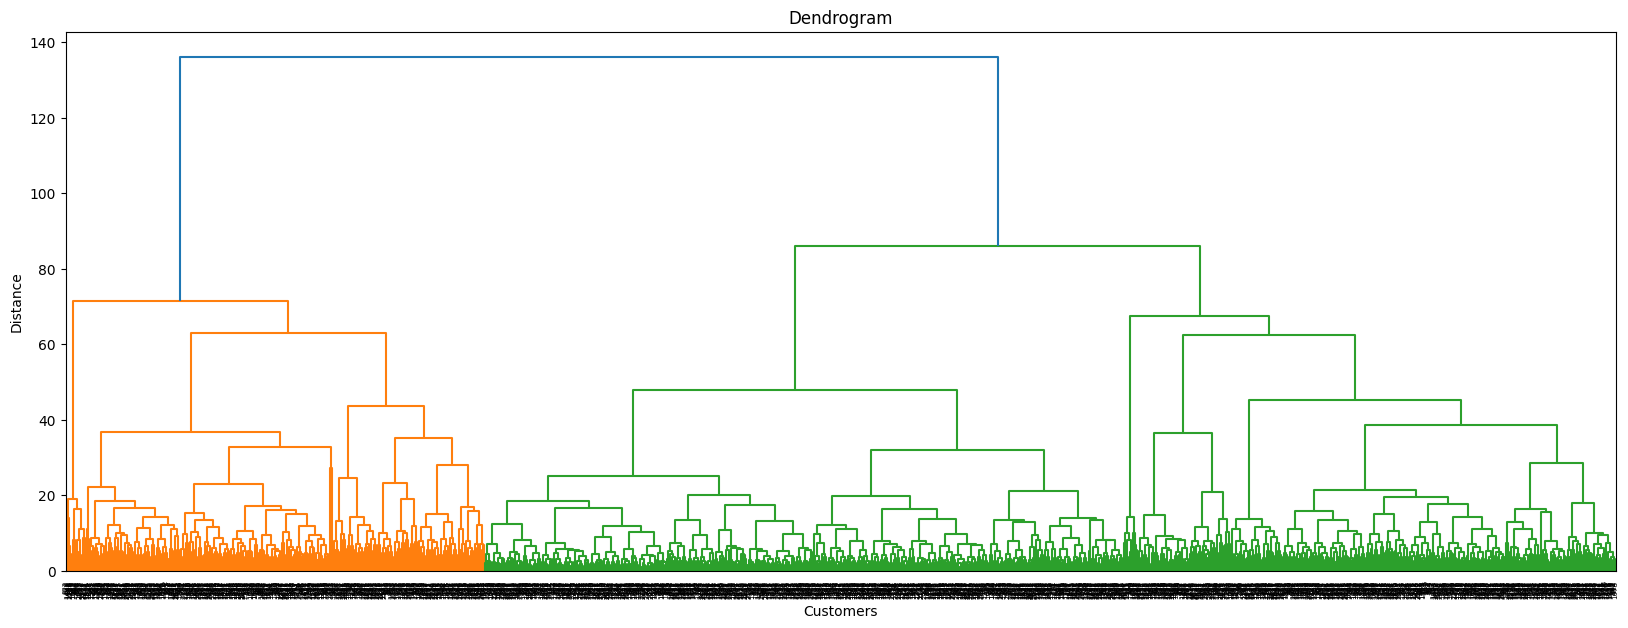

In [366]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(
    X_pca,
    method='ward'
)

plt.figure(figsize=(20,7))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [367]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_pca)

In [368]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_pca,
    agg_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.25334420983762707


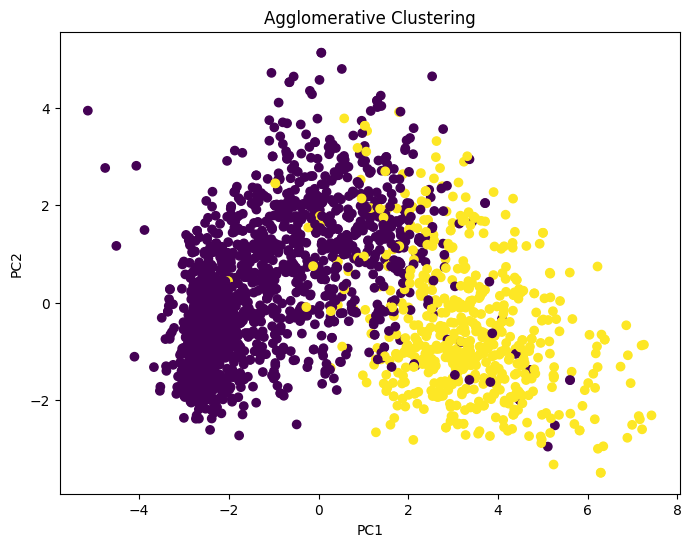

In [369]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(df_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=agg_labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering")

plt.show()

In [370]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=2.0,
    min_samples=10
)

db_labels = db.fit_predict(X_pca)

In [371]:
import pandas as pd

pd.Series(db_labels).value_counts()

,count
-1,1368
0,845
1,27


In [372]:
for eps in [1.5, 2, 2.5, 3, 3.5, 4]:

    db = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = db.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    n_noise = list(labels).count(-1)

    print(
        f"eps={eps} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=1.5 | clusters=3 | noise=1914
eps=2 | clusters=2 | noise=1368
eps=2.5 | clusters=4 | noise=953
eps=3 | clusters=3 | noise=600
eps=3.5 | clusters=6 | noise=357
eps=4 | clusters=6 | noise=209


In [373]:
db = DBSCAN(
    eps=4,
    min_samples=10
)

db_labels = db.fit_predict(X_pca)

In [374]:
n_clusters = len(set(db_labels)) - (
    1 if -1 in db_labels else 0
)

# Noise count
n_noise = list(db_labels).count(-1)

print("Clusters Found :", n_clusters)
print("Noise Points   :", n_noise)

# Cluster distribution
print("\nCluster Distribution")
print(pd.Series(db_labels).value_counts().sort_index())

# Silhouette Score
if n_clusters > 1:

    score = silhouette_score(
        X_pca,
        db_labels
    )

    print("\nSilhouette Score :", score)

Clusters Found : 6
Noise Points   : 209

Cluster Distribution
-1     209
 0    1915
 1      48
 2      11
 3      15
 4      31
 5      11
Name: count, dtype: int64

Silhouette Score : 0.20156102113232047


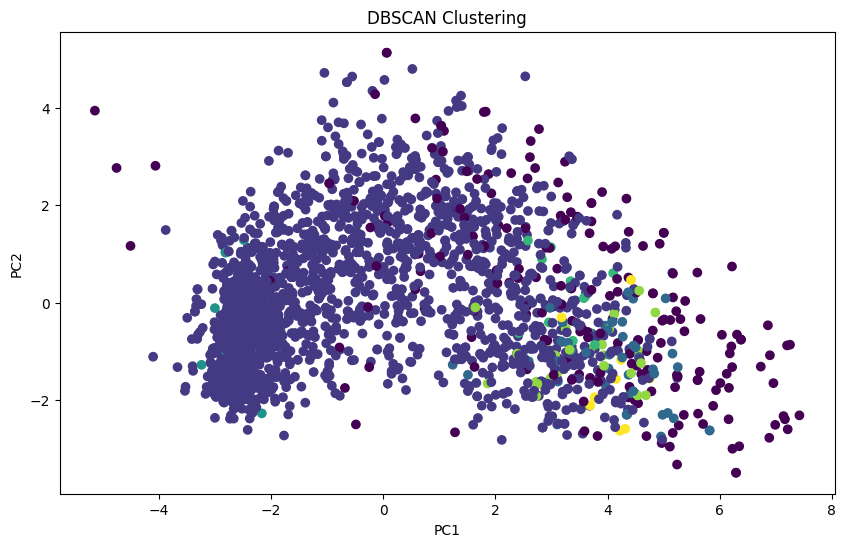

In [375]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_vis = PCA(n_components=2)

X_vis = pca_vis.fit_transform(df_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=db_labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering")

plt.show()

In [376]:
X_vis

array([[ 3.58644341,  0.32775295],
       [-2.38408133, -0.23707015],
       [ 1.68036619, -0.27281738],
       ...,
       [ 1.47317445, -0.1846592 ],
       [ 1.80807598,  0.82380763],
       [-1.87694636,  1.54121016]])

In [377]:
X_vis.shape

(2240, 2)